In [1]:
import os
from pprint import pprint
from dotenv import load_dotenv

# Cargamos las variables de entorno del archivo .env al sistema operativo
load_dotenv()

# Verificamos que la variable se ha cargado
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")



In [13]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import seaborn as snst 

from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

# 1. Cargar el dataset
df_anio = pd.read_csv(f"../Miguel/sheets/csv/climaticos_2026.csv")

# 2. Definir las columnas de interés 
columnas_a_eliminar = [
    'tmax', 'tmin', 'tmed', 'fecha', 'indicativo', 'nombre', 'provincia', 
    'horatmin', 'horatmax', 'horaPresMax', 'horaPresMin', 
    'horaHrMax', 'horaHrMin', 'horaracha',
]


columnas_target = ["tmax", "tmin"]
columnas_features = [col for col in df_anio.columns if col not in columnas_a_eliminar]


df_limpio = df_anio.dropna(subset=columnas_features + columnas_target)


X = df_limpio[columnas_features]
y = df_limpio[columnas_target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


modelo_base = xgb.XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.01)
modelo_base.fit(X_train, y_train)



predicciones = modelo_base.predict(X_test)

error = root_mean_squared_error(y_test, predicciones)

print(f"El modelo falla, de media, unos {error:.2f}°C al predecir el día siguiente.")

El modelo falla, de media, unos 3.31°C al predecir el día siguiente.


In [22]:
resultados = pd.DataFrame({
    'Real Var A': y_test.values[:, 0],
    'Predicción Var A': predicciones[:, 0],
    'Real Var B': y_test.values[:, 1],
    'Predicción Var B': predicciones[:, 1]
})

print(resultados.head(10))

   Real Var A  Predicción Var A  Real Var B  Predicción Var B
0   14.800000         21.315201         2.1          8.357798
1   33.700000         28.336395        12.4         12.592032
2   34.900002         30.061384        15.6         13.270661
3   25.200000         24.952877        11.2         13.277682
4   26.000000         23.112206        15.1         13.929971
5   33.299999         30.979954        16.4         13.871910
6   14.400000         19.807224         7.0         10.267266
7   36.700000         30.951128        18.1         15.180810
8   27.700000         25.584692         9.5         10.644889
9   23.600000         22.328981        16.2         14.376650


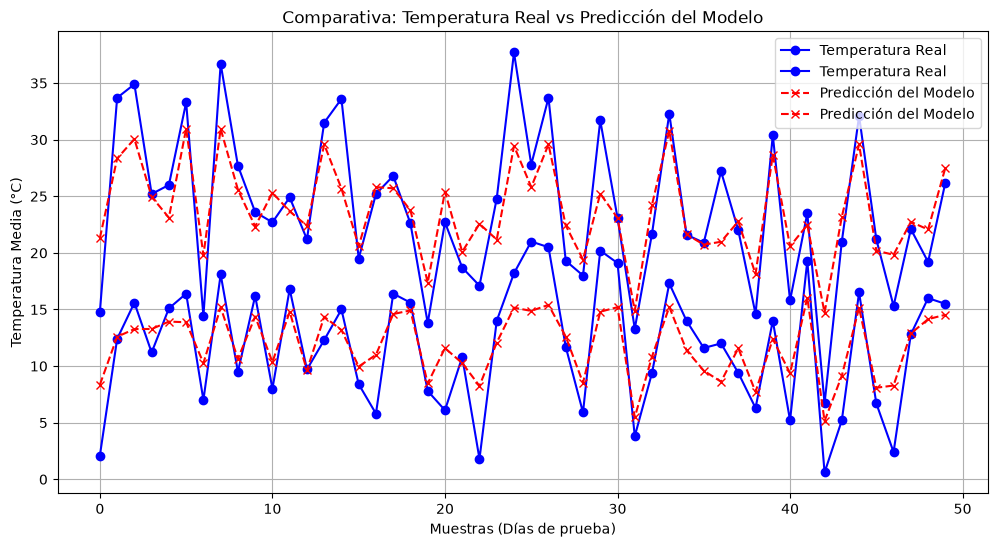

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))


plt.plot(y_test.values[:50], label='Temperatura Real', color='blue', marker='o')


plt.plot(predicciones[:50], label='Predicción del Modelo', color='red', linestyle='--', marker='x')


plt.title('Comparativa: Temperatura Real vs Predicción del Modelo')
plt.xlabel('Muestras (Días de prueba)')
plt.ylabel('Temperatura Media (°C)')
plt.legend() 
plt.grid(True) 


plt.show()

In [ ]:
#relevancia de las columnas al momento de realizar la prediccion 

imp_df: pd.DataFrame = pd.DataFrame({col : imp for col, imp in zip(X_train.columns, modelo_base.feature_importances_)},
                                    index = ["importance"]).T.sort_values(by = "importance", ascending=False)

imp_df

,importance
hrMedia,0.343504
presMin,0.174996
hrMin,0.125375
presMax,0.111895
sol,0.104503
hrMax,0.061479
prec,0.026932
altitud,0.022397
dir,0.011950
velmedia,0.011408


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error


# Ordenamos por fecha 
df_anio = df_anio.sort_values(by=['indicativo', 'fecha'])

# La temperatura media del DÍA SIGUIENTE
# .shift(-1) sube la columna una posición hacia arriba
df_anio['target_tmed_manana'] = df_anio.groupby('indicativo')['tmed'].shift(-1)

# Borramos la última fila de cada estación porque no tiene un "mañana" para predecir
df_anio = df_anio.dropna(subset=['target_tmed_manana'] + columnas_features)



# Seleccionamos nuestras características (Features) y nuestro objetivo (Target)
X = df_anio[columnas_features]  # Lo que el modelo usa para aprender (Datos de HOY)
y = df_anio['target_tmed_manana'] # Lo que el modelo tiene que predecir (Mañana)

#  Dividimos en datos de entrenamiento (80%) y de prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Creamos el modelo 
modelo = RandomForestRegressor(n_estimators=100, random_state=42)

# entrenamiento
modelo.fit(X_train, y_train)

# Evaluamos si el modelo es bueno usando los datos de prueba que guardamos
predicciones = modelo.predict(X_test)

error = root_mean_squared_error(y_test, predicciones)

print(f"El modelo falla, de media, unos {error:.2f}°C al predecir el día siguiente.")


El modelo falla, de media, unos 2.33°C al predecir el día siguiente.


In [ ]:
# tabla con los valores reales y las predicciones
resultados = pd.DataFrame({
    'Temperatura Real (°C)': y_test.values,
    'Predicción del Modelo (°C)': predicciones
})


print(resultados.head(10))

   Temperatura Real (°C)  Predicción del Modelo (°C)
0              27.500000                      26.378
1              17.800000                      19.779
2              21.100000                      19.377
3              14.300000                      12.016
4              28.600000                      24.220
5              24.200001                      19.513
6              21.200000                      20.807
7              17.500000                      19.344
8              15.600000                      19.269
9              18.000000                      20.204


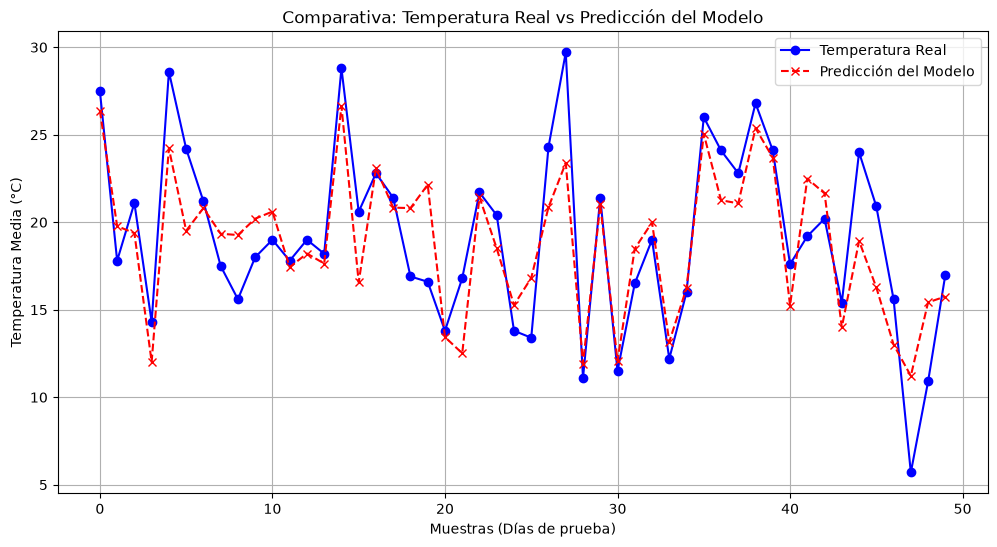

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(y_test.values[:50], label='Temperatura Real', color='blue', marker='o')

plt.plot(predicciones[:50], label='Predicción del Modelo', color='red', linestyle='--', marker='x')

plt.title('Comparativa: Temperatura Real vs Predicción del Modelo')
plt.xlabel('Muestras (Días de prueba)')
plt.ylabel('Temperatura Media (°C)')
plt.legend() 
plt.grid(True) 


plt.show()